In [15]:
!pip install tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Load IMDB raw text
imdb_data, imdb_info = tfds.load(
    "imdb_reviews",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

train_data, test_data = imdb_data

# Convert to lists
imdb_texts = []
imdb_labels = []

for text, label in tfds.as_numpy(train_data):
    imdb_texts.append(text.decode("utf-8"))
    imdb_labels.append(label)

imdb_texts = np.array(imdb_texts)
imdb_labels = np.array(imdb_labels)

print("IMDB training samples:", len(imdb_texts))

IMDB training samples: 25000


In [16]:
# Load GenZ dataset
genz_df = pd.read_csv("cleaned_data.csv")
genz_texts = genz_df["cleaned_text"].astype(str).values

print("GenZ samples:", len(genz_texts))

GenZ samples: 1110


In [17]:
max_words = 20000
max_len = 200

# Combine vocabulary sources
combined_texts = list(imdb_texts) + list(genz_texts)

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(combined_texts)

# Tokenize IMDB
imdb_sequences = tokenizer.texts_to_sequences(imdb_texts)
imdb_padded = pad_sequences(imdb_sequences, maxlen=max_len, padding="post")

In [22]:
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()
model.save("cnn_lstm_imdb_sentiment_model.h5")
print("Model saved.")


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model saved.


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    imdb_padded,
    imdb_labels,
    test_size=0.2,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

loss, accuracy = model.evaluate(X_val, y_val)
print("IMDB Validation Accuracy:", accuracy)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5808 - loss: 0.6511 - val_accuracy: 0.8410 - val_loss: 0.3882
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9069 - loss: 0.2533 - val_accuracy: 0.8786 - val_loss: 0.2956
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9622 - loss: 0.1233 - val_accuracy: 0.8660 - val_loss: 0.3370
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9836 - loss: 0.0642 - val_accuracy: 0.8738 - val_loss: 0.3757
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9913 - loss: 0.0383 - val_accuracy: 0.8708 - val_loss: 0.4557
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8640 - loss: 0.4855
IMDB Validation Accuracy: 0.8708000183105469


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
dl_sentiment   negative   positive
phase                             
after         23.286052  76.713948
before        37.037037  62.962963
during        17.307692  82.692308


<Axes: xlabel='phase'>

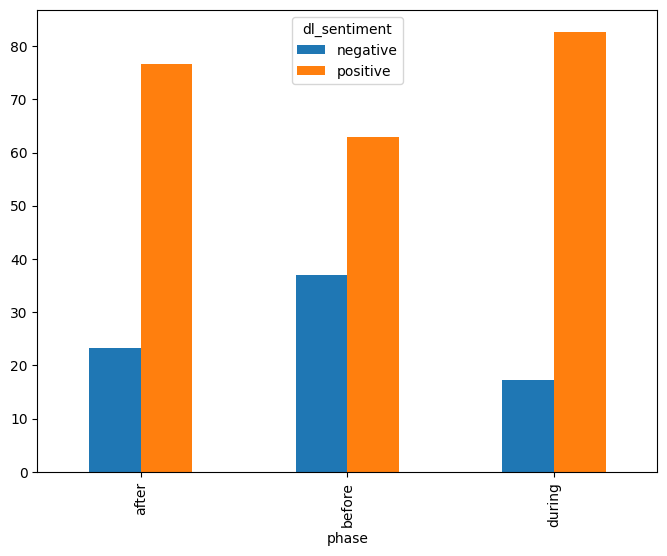

In [24]:
# Tokenize GenZ data using SAME tokenizer
genz_sequences = tokenizer.texts_to_sequences(genz_texts)
genz_padded = pad_sequences(genz_sequences, maxlen=max_len, padding="post")

# Predict sentiment
predictions = model.predict(genz_padded)

genz_df["dl_sentiment"] = (predictions > 0.5).astype(int)
genz_df["dl_sentiment"] = genz_df["dl_sentiment"].map({0: "negative", 1: "positive"})

# Analyze by phase
phase_distribution = genz_df.groupby(["phase", "dl_sentiment"]).size().unstack()
phase_percent = phase_distribution.div(phase_distribution.sum(axis=1), axis=0) * 100

print(phase_percent)

phase_percent.plot(kind="bar", figsize=(8,6))